In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sqlite3
import warnings
warnings.filterwarnings("ignore")


In [2]:
data = pd.read_csv('risk_data.csv', parse_dates=['interaction_time'], date_format='%Y-%m-%d %H:%M:%S')

In [3]:
data.head()

,fullVisitorid,visitId,source,interaction_time,productSKU,action_type,transactionId,merchant
0,10796433617570240226,1537231206,FB,2018-09-18 08:05:10,276921,3,NaN,cashloan
1,3420023669829788288,1537339917,FB,2018-09-19 13:53:09,352156,3,NaN,cashloan
2,260086599438307401,1536730102,FB,2018-09-12 12:49:53,392955,3,NaN,cashloan
3,3156776568682643722,1536885003,FB,2018-09-14 07:30:17,393079,3,NaN,cashloan
4,610658073725040936,1536882984,FB,2018-09-14 06:58:34,393079,3,NaN,cashloan


## Task 1: 
Remove all records with:
- null/other loan product 
- invalid approval status

In [4]:
data["merchant"].unique()

array(['cashloan', 'payday', 'creditcard', nan, 'paylater'], dtype=object)

- As you can see there are four types of loan: cashloan, payday, creditcard and paylater.
- Then, we will remove the nan value, which indicate null or other loan product.

In [5]:
data.dropna(subset=["merchant"],inplace=True)

In [6]:
data["merchant"].unique()

array(['cashloan', 'payday', 'creditcard', 'paylater'], dtype=object)

In [7]:
data['action_type'].unique()

array([3, 6])

- Since action type only exists two unique values, which are 3 and 6. 
- => There are no invalid approval value.

## Task 2: 
- How many customers received loan offers? 
- How many customers accepted the loan offers? 
- Calculate these numbers in total, by date, and by hour

In [8]:
#In total
loan_action = data['action_type'].value_counts().to_frame()
print("Total customers received loan:", loan_action.iloc[0, 0])
print("Total customers accepted loan:", loan_action.iloc[1, 0])

Total customers received loan: 234471
Total customers accepted loan: 45150


- By date

In [9]:
data_by_date = data[['interaction_time', 'action_type']]
data_by_date['action_type'] = data_by_date['action_type'].map({3: 'received', 6: 'accepted'})
data_by_date['date'] = data_by_date['interaction_time'].dt.date
data_by_date = data_by_date.groupby('date')['action_type'].value_counts().to_frame()


In [10]:
display(data_by_date.head())

count
date       action_type       
2018-09-10 received     23805
           accepted      4845
2018-09-11 received     23984
           accepted      4621
2018-09-12 received     24250

- By hour

In [11]:
data_by_hour = data[['interaction_time', 'action_type']]
data_by_hour['action_type'] = data_by_hour['action_type'].map({3: 'received', 6: 'accepted'})
data_by_hour['hour'] = data_by_hour['interaction_time'].dt.hour
data_by_hour = data_by_hour.groupby('hour')['action_type'].value_counts().to_frame()

In [12]:
display(data_by_date.head())

count
date       action_type       
2018-09-10 received     23805
           accepted      4845
2018-09-11 received     23984
           accepted      4621
2018-09-12 received     24250

- By date and hour

In [13]:
data_by_dhour = data[['interaction_time', 'action_type']]
data_by_dhour['action_type'] = data_by_dhour['action_type'].map({3: 'received', 6: 'accepted'})
data_by_dhour['date hour'] = data_by_dhour['interaction_time'].dt.strftime('%Y-%m-%d %H').astype(str)
data_by_dhour = data_by_dhour.groupby(['date hour'])['action_type'].value_counts().to_frame()

In [14]:
data_by_dhour

count
date hour     action_type       
2018-09-10 00 received       745
              accepted       108
2018-09-10 01 received       278
              accepted        50
2018-09-10 02 received       146
...                          ...
2018-09-19 21 accepted       262
2018-09-19 22 received      1602
              accepted       268
2018-09-19 23 received      1012
              accepted       154

[479 rows x 1 columns]

## Task 3:
- Calculate the Loan Offer Acceptance Rate
- The percentage of approved customers who do not proceed to sign the loan agreement within a specific time range

---

- Define formula based on definition 
- $Loan\ Offer\ Acceptance\ Rate\ =\ \frac{action\ type\ is\ 6}{action\ type\ is\ 3}$

In [15]:
acceptances_rates = data_by_dhour.copy()
acceptances_rates['acceptance_rate'] = acceptances_rates.groupby(level=0)['count'].shift(-1) / acceptances_rates['count']
"""
Explain:
shift(-1) will take the value of next action(accepted) alligned with the same current row (received)
and then we take the shifted value / current value
"""
display(acceptances_rates.head(4))

count  acceptance_rate
date hour     action_type                        
2018-09-10 00 received       745         0.144966
              accepted       108              NaN
2018-09-10 01 received       278         0.179856
              accepted        50              NaN

In [16]:
## filter out all NaN rows
acceptances_rates = acceptances_rates[~acceptances_rates['acceptance_rate'].isna()]
acceptances_rates.reset_index(level=1, inplace=True)
acceptances_rates.drop(columns='action_type', inplace=True)

In [17]:
print("Loan acceptance rates by hour")
display(acceptances_rates)

Loan acceptance rates by hour


,count,acceptance_rate
date hour,,
2018-09-10 00,745,0.144966
2018-09-10 01,278,0.179856
2018-09-10 02,146,0.171233
2018-09-10 03,101,0.118812
2018-09-10 04,101,0.118812
...,...,...
2018-09-19 19,1271,0.151849
2018-09-19 20,1608,0.142413
2018-09-19 21,1710,0.153216


## Task 4
- Is there any relationship between loan product type and Loan Offer Acceptance Rate?

---

To answer question:
1. Calculate loan acceptance rate by each product.
2. Visualize two factors product category and rate to detect the relationship.

In [18]:
product_loan_offer = data[["interaction_time", "merchant", "action_type"]]
product_loan_offer["date hour"] = product_loan_offer["interaction_time"].dt.strftime('%Y-%m-%d %H').astype(str)


In [19]:
product_loan_offer = product_loan_offer.groupby('merchant')['action_type'].value_counts().to_frame()
# Compute acceptance rate for each product.
product_loan_offer['acceptance_rate'] = product_loan_offer.groupby(level=0)['count'].shift(-1) / product_loan_offer['count']
product_loan_offer = product_loan_offer[~product_loan_offer['acceptance_rate'].isna()]

# Set index, unimportant code.
product_loan_offer.reset_index(level=1, inplace=True)
product_loan_offer.drop(columns='action_type', inplace=True)
product_loan_offer.sort_values(by='acceptance_rate', inplace=True)

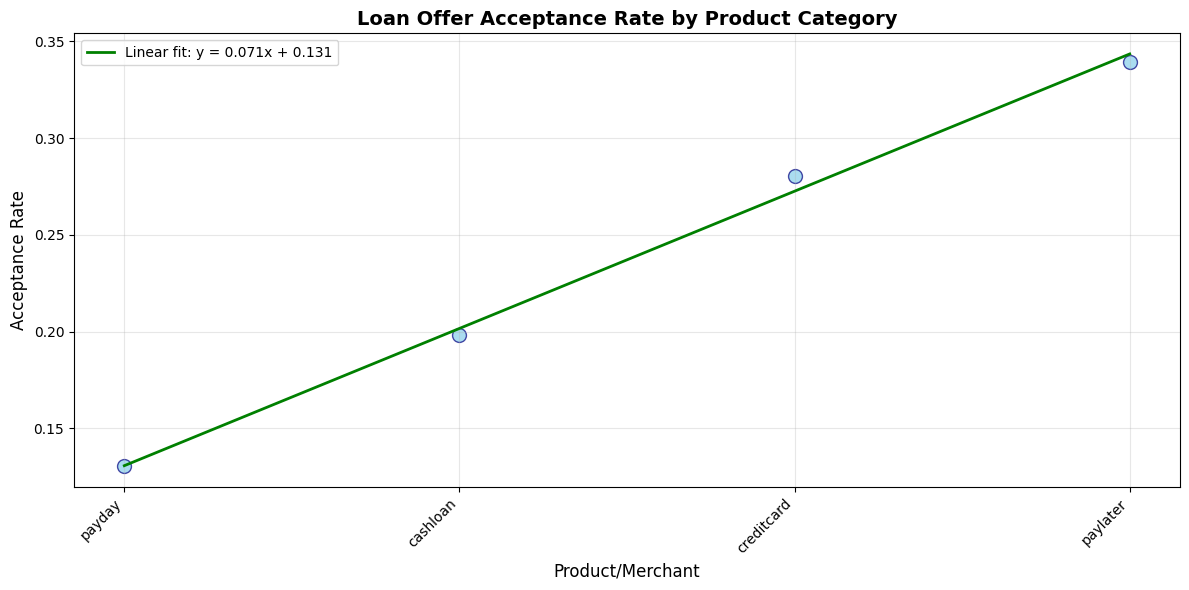

In [20]:
plt.figure(figsize=(12, 6))
plt.scatter(product_loan_offer.index, product_loan_offer['acceptance_rate'], 
           s=100, alpha=0.7, color='skyblue', edgecolors='navy', linewidth=1)
plt.xlabel('Product/Merchant', fontsize=12)
plt.ylabel('Acceptance Rate', fontsize=12)
plt.title('Loan Offer Acceptance Rate by Product Category', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Fit linear regression line
x_numeric = np.arange(len(product_loan_offer))
slope, intercept = np.polyfit(x_numeric, product_loan_offer['acceptance_rate'], 1)
plt.plot(product_loan_offer.index, slope * x_numeric + intercept, color='green', linewidth=2, label=f'Linear fit: y = {slope:.3f}x + {intercept:.3f}')

plt.legend()
plt.tight_layout()


In [21]:
from scipy.stats import pearsonr

# Compute correlation between product order and acceptance rate
x_numeric = np.arange(len(product_loan_offer))
correlation, p_value = pearsonr(x_numeric, product_loan_offer['acceptance_rate'])

print(f"Pearson Correlation Coefficient: {correlation:.4f}")

Pearson Correlation Coefficient: 0.9982


There is highly correlation between the two factors - product category and loan acceptance rate, which is proved by:

- Visualization of two factors exhibiting a fitted linear line between two factors.
- Pearson correlation is 0.9982 (approximate 1) => highly correlation

## Task 5 + Task 6:
- Calculate the average time lag from when a loan offer is first presented to when the customer accepts the loan offer
- In cases where a customer receives **multiple loan offers or has multiple application IDs** \
=> Consider only the loan offers presented within the time interval between two consecutive applications or approval events


In [22]:
time_frame = data.copy()
time_frame = time_frame.sort_values(["fullVisitorid", "interaction_time"])

# For task 6:
# Using shift to consider two consecutive event of a customer
time_frame['next_time'] = time_frame.groupby('fullVisitorid')['interaction_time'].shift(-1)
time_frame['next_action'] = time_frame.groupby('fullVisitorid')['action_type'].shift(-1)

In [23]:
time_frame.head(3)

,fullVisitorid,visitId,source,interaction_time,productSKU,action_type,transactionId,merchant,next_time,next_action
192576,10519906921277,1536655412,facebook,2018-09-11 15:55:02,3271393,3,NaN,payday,2018-09-11 15:55:06,3.0
187274,10519906921277,1536655412,facebook,2018-09-11 15:55:06,2100159,3,NaN,payday,NaT,NaN
204965,199495647118945,1536627993,products,2018-09-11 08:13:08,276921,3,NaN,cashloan,NaT,NaN


In [24]:
result = time_frame[(time_frame['action_type'] == 3) & (time_frame['next_action'] == 6)]
result['time_lag'] = (result['next_time'] - result['interaction_time']).dt.total_seconds() / 3600

In [25]:
print("Average time lag from when a loan offer is first presented to when the customer accepts the loan offer: ", f"{result['time_lag'].mean():.2f}", "hours")

Average time lag from when a loan offer is first presented to when the customer accepts the loan offer:  9.64 hours


<Axes: xlabel='time_lag', ylabel='Count'>

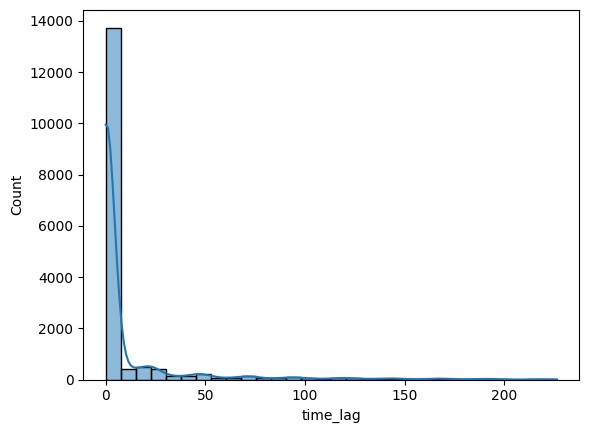

In [26]:
sns.histplot(np.clip(result['time_lag']), bins=30, kde=True)

## Task 7:
- Are there any other insights you find interesting that could bring business value to the lending business? (This is an open-ended question. Candidates are encouraged to explore any insights from the available data and may also incorporate relevant real-world knowledge where appropriate.)

In [27]:
insights_frame = time_frame[~time_frame['next_action'].isna()]

In [28]:
insights_frame['source'] = insights_frame['source'].apply(lambda x: "facebook" if ("facebook" in x.lower() or "fb" in x.lower())else x)
insights_frame['source'] = insights_frame['source'].apply(lambda x: "google" if "google" in x.lower() else x)
insights_frame['source'] = insights_frame['source'].apply(lambda x: "youtube" if "youtube" in x.lower() else x)
top_sources = insights_frame["source"].value_counts().index[:20]
insights_frame["top_source"] = insights_frame["source"].apply(lambda x: x if x in top_sources else "Other")
source_insights = insights_frame.groupby('top_source').agg(
    total_offers=('action_type', lambda x: (x == 3).sum()),
    total_acceptances=('next_action', lambda x: (x == 6).sum())
)

In [29]:
source_insights['acceptance_rate'] = source_insights['total_acceptances'] / source_insights['total_offers']
source_insights.sort_values(by='acceptance_rate', inplace=True)

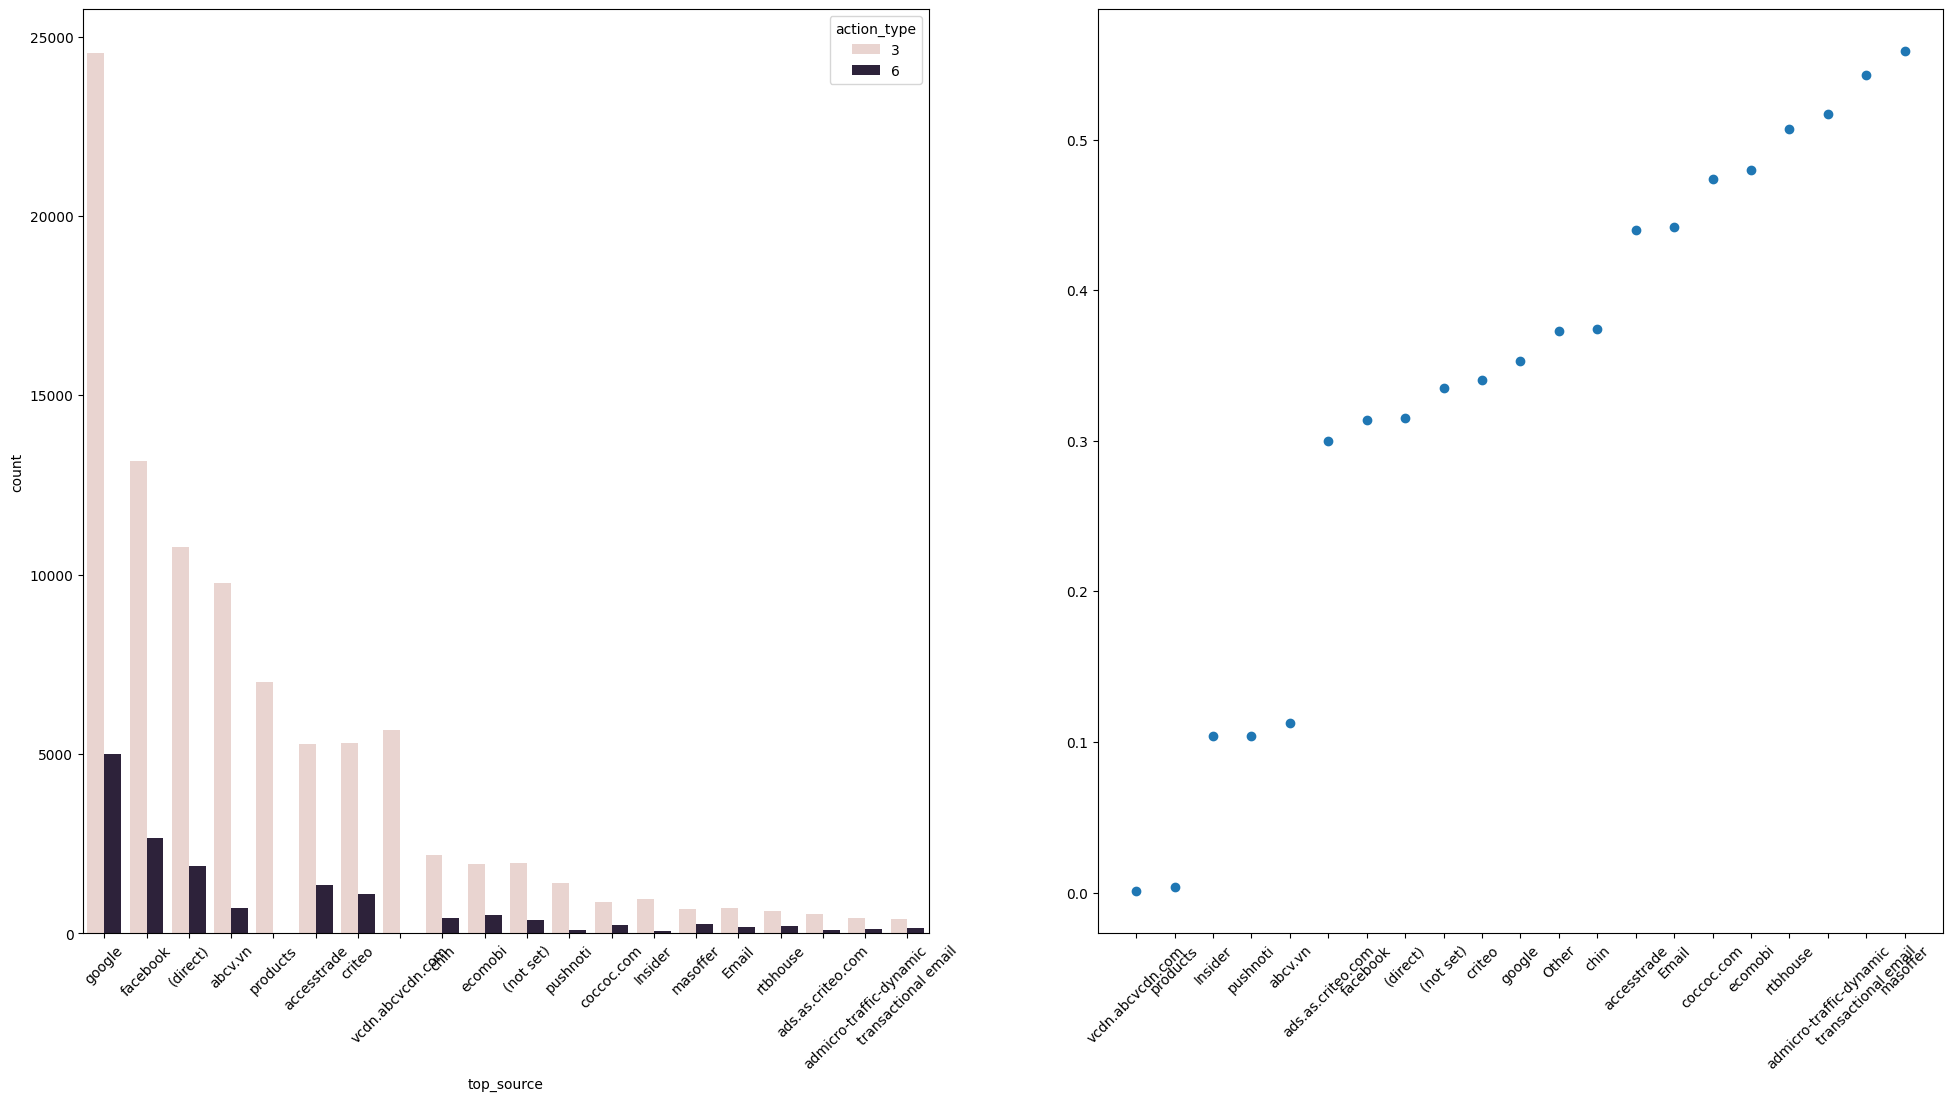

In [30]:

fig, ax = plt.subplots(1, 2,figsize=(24, 12))
sns.countplot(data=insights_frame, x="top_source", order=top_sources, hue="action_type", ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

ax[1].scatter(source_insights.index, source_insights['acceptance_rate'])
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)
plt.show()

- Insight: there is a correlation between source and acceptance rate. While some source get higher acceptance rate the other likely get 0% acceptance.

- While some channels are send a lot of offers, the acceptance rate is not higher with some low traffic channel. For example, facebook compared to criteo.

=> So we can think of switching main channels for offering which get higher efficient.

In [31]:
insights_frame.sort_values(by='interaction_time', inplace=True)
time_insights = insights_frame[insights_frame['action_type'] == 3]
time_insights = time_insights.groupby('fullVisitorid').agg(
    interaction_duration=('interaction_time', lambda x: (x.max() - x.min()).total_seconds() / 3600),
    frequency=('interaction_time', 'count'),
    offers=('action_type', lambda x: (x == 3).sum()),
    acceptances=('next_action', lambda x: (x == 6).sum())
)

<Axes: xlabel='acceptances', ylabel='Count'>

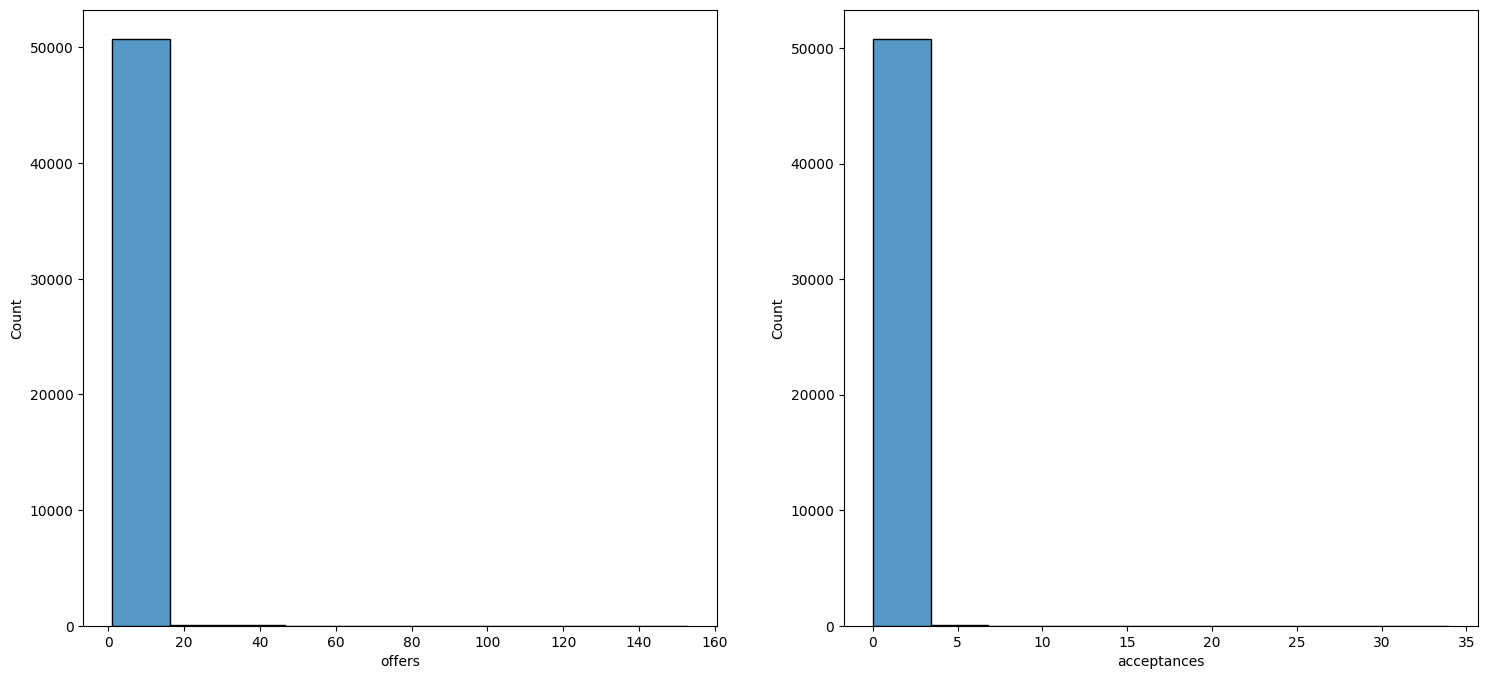

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.histplot(time_insights, x="offers", bins=10, ax=axes[0])
sns.histplot(time_insights, x="acceptances", bins=10, ax=axes[1])

- There are many customers who continue to accept the offers while the other only accept the offer once time.\
=> We can segment them into different categories of customer who are a long-term customer or not, which may help for further marketing campaign.

## Task 8:
- Can we build an early warning rule to identify approved customers who are unlikely to sign within the expected time window?

- Yes, we can build an early warning rule. 
- Generate label for training model based on expected time window:
    + Logic (example): \
        ![Screenshot from 2026-04-18 23-27-57.png](<attachment:Screenshot from 2026-04-18 23-27-57.png>)


    + In this case, after label creation (warning feature), the result is:

   ![Screenshot from 2026-04-18 23-29-05.png](<attachment:Screenshot from 2026-04-18 23-29-05.png>)

    The label will be depened on whether the offer action(3) finally get signed(6) => warning = 0 \
    If final action is NaN(in expected time window) => warning = 1

- The training experiment will be devided into two parts, one is about using current features, and the other is about adding more features.

- Models: xgboost, lightgbm.

- Metrics: roc-auc.

- **For short, you can scroll to the end to see the performance of different experiments.**

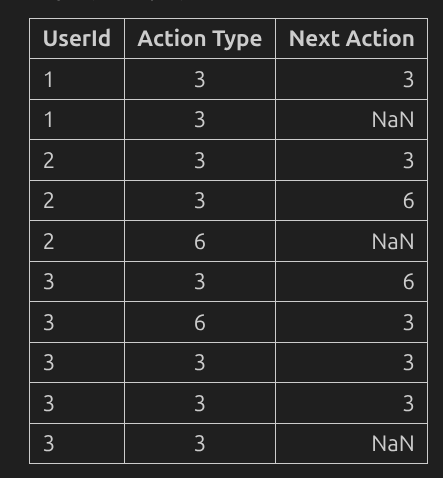
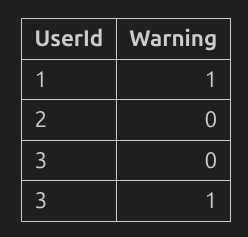

In [33]:
performance = []

action_frame = time_frame[(time_frame['next_action'] != 3) & (time_frame['action_type'] != 6)]
action_frame['warning'] = 0
action_frame.loc[action_frame['next_action'].isna(), 'warning'] = 1
display(action_frame.head(3))
action_frame.drop(['fullVisitorid', 'visitId', 'transactionId', 'next_time', 'next_action', 'action_type'], axis=1, inplace=True)
action_frame.set_index('interaction_time', inplace=True)
action_frame.sort_index(inplace=True)

,fullVisitorid,visitId,source,interaction_time,productSKU,action_type,transactionId,merchant,next_time,next_action,warning
187274,10519906921277,1536655412,facebook,2018-09-11 15:55:06,2100159,3,NaN,payday,NaT,NaN,1
204965,199495647118945,1536627993,products,2018-09-11 08:13:08,276921,3,NaN,cashloan,NaT,NaN,1
204092,202446079418495,1537270170,products,2018-09-18 18:30:40,205508,3,NaN,creditcard,NaT,NaN,1


- build baseline warning system

<Axes: xlabel='warning'>

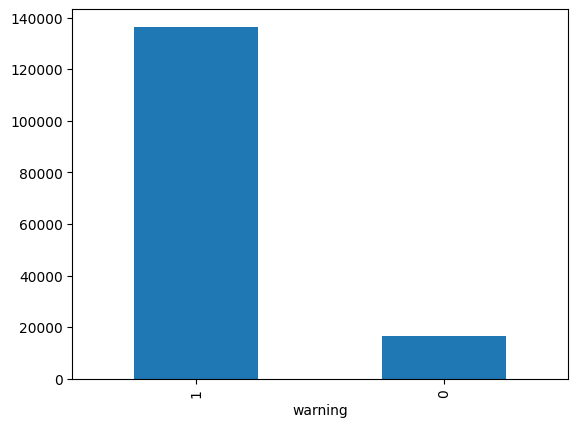

In [34]:
action_frame['warning'].value_counts().plot(kind="bar")

=> There are imbalanced labels, so I will add weight penalties to solve the problem

In [35]:
n = len(action_frame)
train_size = int(n * 0.8)
train_data = action_frame.iloc[:train_size]
test_data = action_frame.iloc[train_size:]
X_train, X_test = train_data.drop('warning', axis=1), test_data.drop('warning', axis=1)
y_train, y_test = train_data['warning'], test_data['warning']

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

def plot_confusion_matrix(y_true, y_pred, labels=None, title='Confusion Matrix', cmap='Blues'):
    """Plot a confusion matrix for classification results."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap=cmap, values_format='d', ax=ax)
    ax.set_title(title)
    plt.show()
    plt.tight_layout()
    return fig, ax

# Example usage:
# plot_confusion_matrix(y_test, y_pred_xgb, title='XGBoost Confusion Matrix')
# plot_confusion_matrix(y_test, y_pred, title='LightGBM Confusion Matrix')


In [38]:
cat_features = ['source', 'merchant']
num_features = ['productSKU']

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
sample_weight = np.where(y_train == 0, class_weights[0], class_weights[1])

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

              precision    recall  f1-score   support

           0       0.13      0.82      0.23      2670
           1       0.97      0.49      0.65     27926

    accuracy                           0.51     30596
   macro avg       0.55      0.65      0.44     30596
weighted avg       0.89      0.51      0.61     30596



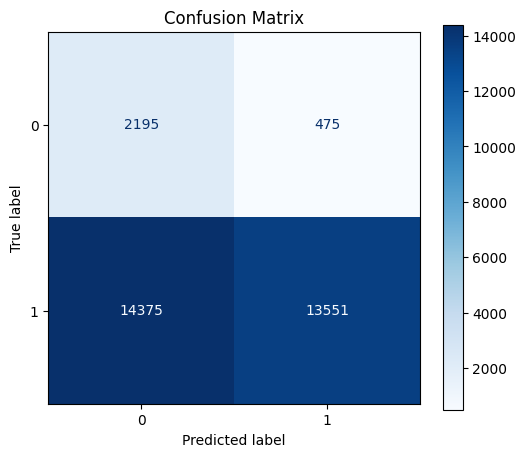

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>)

<Figure size 640x480 with 0 Axes>

In [40]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train_processed, y_train, sample_weight=sample_weight)
y_pred_xgb = xgb.predict(X_test_processed)
performance.append(
    {"Model": "xgboost", "type": "baseline", "roc_auc_score": roc_auc_score(y_test, xgb.predict_proba(X_test_processed)[:, 1])}
)
print(classification_report(y_test, y_pred_xgb))
plot_confusion_matrix(y_test, y_pred_xgb)

[LightGBM] [Info] Number of positive: 108476, number of negative: 13907
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 425
[LightGBM] [Info] Number of data points in the train set: 122383, number of used features: 86
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.886365 -> initscore=2.054137
[LightGBM] [Info] Start training from score 2.054137
              precision    recall  f1-score   support

           0       0.13      0.84      0.23      2670
           1       0.97      0.47      0.63     27926

    accuracy                           0.50     30596
   macro avg       0.55      0.66      0.43     30596
weighted avg       0.90      0.50      0.60     30596



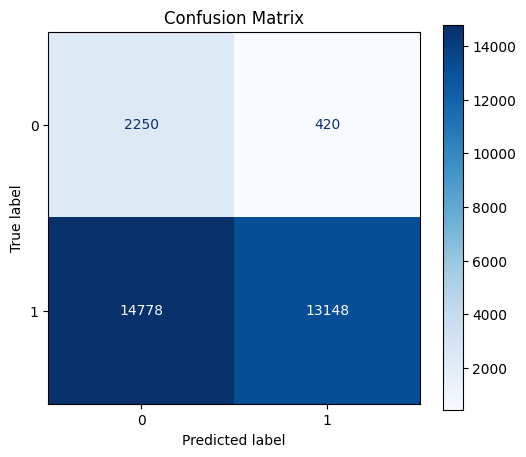

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>)

<Figure size 640x480 with 0 Axes>

In [41]:
import lightgbm
train_data=lightgbm.Dataset(X_train_processed, y_train)
params={
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'scale_pos_weight': class_weights[1] / class_weights[0]
}
model = lightgbm.train(params, train_data, num_boost_round=100)

y_pred_lgb = model.predict(X_test_processed)
y_pred=(y_pred_lgb>0.5).astype(int)
performance.append({"Model": "lightgbm", "type": "baseline", "roc_auc_score": roc_auc_score(y_test, y_pred_lgb)})
print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred, title="Confusion Matrix")

=> since we interest more about customers who will not continue to proceed to sign (labelled 1) than label 0 customer, so system is likely good for the case. The main reason is because majority of customers in label 1.

However we will try to build more robust warning system.

In [42]:
action_frame_2 = time_frame.copy()
action_frame_2['source'] = action_frame_2['source'].apply(lambda x: "website" if len(x.split('.')) > 1 else x)
action_frame_2['source'] = action_frame_2['source'].apply(lambda x: "facebook" if ("facebook" in x.lower() or "fb" in x.lower())else x)
action_frame_2['source'] = action_frame_2['source'].apply(lambda x: "google" if "google" in x.lower() else x)
action_frame_2['source'] = action_frame_2['source'].apply(lambda x: "youtube" if "youtube" in x.lower() else x)
action_frame_2['source'] = action_frame_2['source'].apply(lambda x: "coccoc" if "coccoc" in x.lower() else x)
action_frame_2['source'] = action_frame_2['source'].apply(lambda x: "message" if x.lower() in ["message", "messenger", "email", "zalo", "yahoo"] else x)
inlist = action_frame_2['source'].value_counts().index[:20]
action_frame_2['source'] = action_frame_2['source'].apply(lambda x: "other" if x not in inlist else x)

In [43]:
action_frame_2['frequency'] = action_frame_2.groupby('fullVisitorid').cumcount() + 1
action_frame_2['period_latest'] = action_frame_2.groupby('fullVisitorid')['interaction_time'].diff().fillna(pd.Timedelta(seconds=0)).dt.total_seconds()
action_frame_2['period_farest'] = (action_frame_2['interaction_time'] - action_frame_2.groupby('fullVisitorid')['interaction_time'].transform('first')).dt.total_seconds()


In [44]:
action_frame_2 = action_frame_2[(action_frame_2['action_type'] != 6) & (action_frame_2['next_action'] != 3)] 
action_frame_2['warning'] = 0
action_frame_2.loc[action_frame_2['next_action'].isna(), 'warning'] = 1

In [45]:
action_frame_2.drop(['fullVisitorid', 'visitId', 'transactionId', 'next_time', 'next_action', 'action_type'], axis=1, inplace=True)

In [46]:
action_frame_2['duration'] = (action_frame_2['period_farest'] + 0.01) * action_frame_2['frequency']

In [47]:
merchant_map = {'payday': 0,
 'cashloan': 1,
 'creditcard': 2,
 'paylater': 3}

In [48]:
action_frame_2['merchant'] = action_frame_2['merchant'].map(merchant_map)

In [49]:
action_frame_2.set_index('interaction_time', inplace=True)


In [50]:
action_frame_2.sort_index(inplace=True)

In [51]:
n = len(action_frame_2)
train_size = int(n * 0.8)
train_data = action_frame_2.iloc[:train_size]
test_data = action_frame_2.iloc[train_size:]
X_train, X_test = train_data.drop('warning', axis=1), test_data.drop('warning', axis=1)
y_train, y_test = train_data['warning'], test_data['warning']

In [52]:
cat_features = ['source']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ], remainder='passthrough')
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

              precision    recall  f1-score   support

           0       0.36      0.06      0.11      2670
           1       0.92      0.99      0.95     27926

    accuracy                           0.91     30596
   macro avg       0.64      0.53      0.53     30596
weighted avg       0.87      0.91      0.88     30596



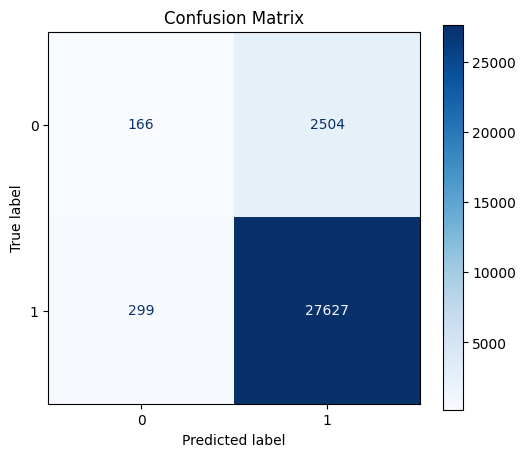

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>)

<Figure size 640x480 with 0 Axes>

In [53]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train_processed, y_train)
y_pred_xgb = xgb.predict(X_test_processed)
performance.append({
    "Model": "xgboost", "type": "add features", "roc_auc_score": roc_auc_score(y_test, xgb.predict_proba(X_test_processed)[:, 1])
})
print(classification_report(y_test, y_pred_xgb))
plot_confusion_matrix(y_test, y_pred_xgb)

[LightGBM] [Info] Number of positive: 108476, number of negative: 13907
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1137
[LightGBM] [Info] Number of data points in the train set: 122383, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.886365 -> initscore=2.054137
[LightGBM] [Info] Start training from score 2.054137
              precision    recall  f1-score   support

           0       0.15      0.67      0.24      2670
           1       0.95      0.64      0.76     27926

    accuracy                           0.64     30596
   macro avg       0.55      0.65      0.50     30596
weighted avg       0.88      0.64      0.72     30596



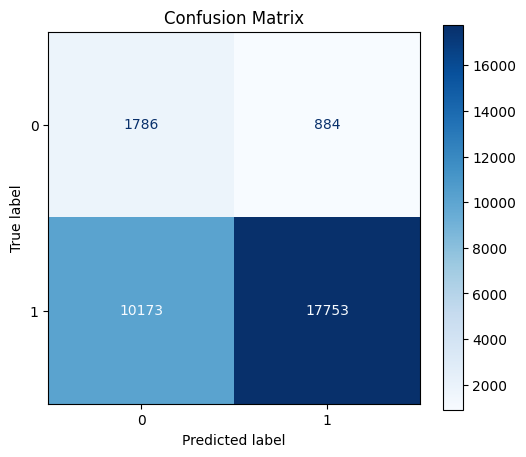

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>)

<Figure size 640x480 with 0 Axes>

In [54]:
import lightgbm
train_data=lightgbm.Dataset(X_train_processed, y_train)
params={
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'scale_pos_weight': class_weights[1] / class_weights[0] # Apply weight penalty for imbalanced classed
}
model = lightgbm.train(params, train_data, num_boost_round=100)

y_pred_lgb = model.predict(X_test_processed)
y_pred=(y_pred_lgb>0.5).astype(int)
performance.append(
    {"Model": "lightgbm", "type": "add features", "roc_auc_score": roc_auc_score(y_test, y_pred_lgb)}
)
print(classification_report(y_test, y_pred))
plot_confusion_matrix(y_test, y_pred)

- Result of different model performance

In [55]:
pd.DataFrame(performance)

,Model,type,roc_auc_score
0,xgboost,baseline,0.710561
1,lightgbm,baseline,0.713648
2,xgboost,add features,0.710117
3,lightgbm,add features,0.718737


=> The highest roc auc score belong to lightgbm model with feature adds.